### Modèle DBSCAN

## Objectif
Entraîner notre IA avec le modèle DBSCAN

Petit rappel de la structure :
```
class sklearn.cluster.DBSCAN(eps=0.5, *, min_samples=5, metric='euclidean', metric_params=None, algorithm='auto', leaf_size=30, p=None, n_jobs=None)
```

Pour la réflexion et l'analyse derrière l'utilisation du modèle DBSCAN se référencer au fichier `DBSCAN.md`

## Code

### Initialisation du dataset et des imports

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn import metrics
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD

      Unnamed: 0  Chiffre                                         Temoignage
0              0        1  The feverish feeling eased, but I’m now breath...
1              1        2  While working in the garden, I touched a metal...
2              2        3  A short sprint brought on a twinge in the midd...
3              3        4  I accidentally left my hand on a hot mug for a...
4              4        5  A sudden twist while reaching for a bag made o...
...          ...      ...                                                ...
1005        1005     1006  I slammed my fingertip in a drawer. The tip is...
1006        1006     1007  I woke up with a throbbing pain in my left ear...
1007        1007     1008  During the summer, my throat gets itchy and I ...
1008        1008     1009  Pushing off during a brisk walk makes the big ...
1009        1009     1010  Every morning I wake up with a pounding headac...

[1010 rows x 3 columns]


In [ ]:
try:
    dfAll = pd.read_csv("../../Student_Clean.csv") # Ouvre le csv
except FileNotFoundError:
    raise SystemExit(84)

X = dfAll['Temoignage']
print(dfAll)


### Vectorisation

#### TfidfVectorizer

In [ ]:
try:
    df = pd.read_csv("../../Student_Clean.csv") # Ouvre le csv
except FileNotFoundError:
    raise SystemExit(84)

# on prend les témoignages et on gère les fillna au cas où
texts = df['Temoignage'].fillna("")

vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(texts)
print(X)


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13653 stored elements and shape (1010, 2135)>
  Coords	Values
  (0, 629)	0.28128336815357885
  (0, 622)	0.1754406074423453
  (0, 533)	0.31467304162000953
  (0, 178)	0.2245062412154984
  (0, 614)	0.3039239676520504
  (0, 523)	0.21450402122071757
  (0, 578)	0.3480627150864402
  (0, 381)	0.16917580307282135
  (0, 996)	0.1980812069408168
  (0, 796)	0.27053429418561975
  (0, 311)	0.26175166126439275
  (0, 1709)	0.21302171607150902
  (0, 621)	0.11396012642891888
  (0, 1000)	0.15003733197004704
  (0, 1051)	0.2877157244009905
  (0, 349)	0.32853100819725406
  (1, 2109)	0.309074506524673
  (1, 714)	0.3440404554964395
  (1, 1916)	0.2509273567479875
  (1, 1080)	0.309074506524673
  (1, 748)	0.3440404554964395
  (1, 1745)	0.309074506524673
  (1, 980)	0.19045890862375647
  (1, 685)	0.22788608724273055
  (1, 215)	0.24353191499846508
  :	:
  (1008, 921)	0.24582700042803093
  (1008, 1733)	0.2180964925489485
  (1008, 1356)	0.21472521265768402


### Fonction d'entraînement et de mesure

In [100]:
def Training(eps):
    """
    Prend en paramètre `eps` un nombre float
    La fonction train le modèle et renvoie des valeurs textuelles et chiffres pour juger de sa précision
    Elle renvoie des print textuels avec données
    """

    # Entraînement du modèle avec nos paramètres
    db = DBSCAN(eps=eps, min_samples=10).fit(X)
    labels = db.labels_
    
    # on calcule le nombre de clusters et de bruit (le bruit étant les points non présents dans un cluster)
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)

    # On ne garde que les clusters supérieurs à 0 pour plus de pertinence et également pour utiliser `silhouette_score`
    if (n_clusters_ > 1):
        print("Nombre de cluster estimes: ", n_clusters_)
        print("Nombre de point de bruit:",  % n_noise_) 
        # on calcule la silhouette (score de précision compris entre -1 et 1, 1 étant le plus précis)
        silhouette = silhouette_score(X, labels, metric="cosine")
        print("Score de precision/ accurate:", silhouette)

        # compteurs de répartition des clusters, permet d'analyser les répartitions des points dans tel ou tel groupe
        valeurs, comptes = np.unique(labels, return_counts=True)
        print("Repartitions des clusters:")
        for val, compte in zip(valeurs, comptes):
            print(f"Cluster {val} : {compte} points")

SyntaxError: invalid syntax (25444444.py, line 19)

### Fonction d'entraînement et de mesure avec utilisation de TruncatedSVD

In [96]:
# utilisation de TruncatedSVD pour prendre les 50 grands axes vectorisés
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduit = svd.fit_transform(X)


def TrainingSVD(eps):
    """
    Prend en paramètre `eps` un nombre float
    La fonction train le modèle et renvoie des valeurs textuelles et chiffres pour juger de sa précision
    Elle renvoie des print textuels avec données
    """
    # Entraînement du modèle avec nos paramètres
    db = DBSCAN(eps=eps, min_samples=10).fit(X_reduit)
    labels = db.labels_
    
    # on calcule le nombre de clusters et de bruit (le bruit étant les points non présents dans un cluster)
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)

    # On ne garde que les clusters supérieurs à 0 pour plus de pertinence et également pour utiliser `silhouette_score`
    if (n_clusters_ > 1):
        print("Estimated number of clusters: %d" % n_clusters_)
        print("Estimated number of noise points: %d" % n_noise_) 
        # on calcule la silhouette (score de précision compris entre -1 et 1, 1 étant le plus précis)
        silhouette = silhouette_score(X_reduit, labels, metric="cosine")
        print("Score de precision/ accurate:", silhouette)

         # compteurs de répartition des clusters, permet d'analyser les répartitions des points dans tel ou tel groupe
        valeurs, comptes = np.unique(labels, return_counts=True)
        print("Répartition des clusters :")
        for val, compte in zip(valeurs, comptes):
            print(f"Cluster {val} : {compte} points")

        return esp, silhouette

### Lancement de la fonction d'entraînement avec différents paramètres pour trouver le meilleur

In [98]:
# borne finale 
end = 2
# borne de début
tp = 0.01

# sauvegarde du meilleur paramètre eps
best_eps = 0
best_value = -1

# boucle qui va appeler la fonction d'entraînement en ajoutant 0.01 en eps
while (tp < end):
    esp_Resultat, silhouette_Resultat = Training(tp)
    if (silhouette_Resultat > best_value):
        best_value = silhouette_Resultat
        best_eps = esp_Resultat
    
    tp += 0.01

print(best_eps)

Estimated number of clusters: 2
Estimated number of noise points: 898
Score de precision/ accurate: -0.020565683388576082
Répartition des clusters :
Cluster -1 : 898 points
Cluster 0 : 102 points
Cluster 1 : 10 points
Estimated number of clusters: 4
Estimated number of noise points: 845
Score de precision/ accurate: -0.04361980236277132
Répartition des clusters :
Cluster -1 : 845 points
Cluster 0 : 128 points
Cluster 1 : 19 points
Cluster 2 : 10 points
Cluster 3 : 8 points
Estimated number of clusters: 2
Estimated number of noise points: 795
Score de precision/ accurate: -0.0027059352118685167
Répartition des clusters :
Cluster -1 : 795 points
Cluster 0 : 195 points
Cluster 1 : 20 points
Estimated number of clusters: 2
Estimated number of noise points: 497
Score de precision/ accurate: -0.02382368675763246
Répartition des clusters :
Cluster -1 : 497 points
Cluster 0 : 505 points
Cluster 1 : 8 points
Estimated number of clusters: 2
Estimated number of noise points: 430
Score de precisio

### Découverte de l'effet de chaîne (Chaining effect), et conclusion.

## Graphique Analyse

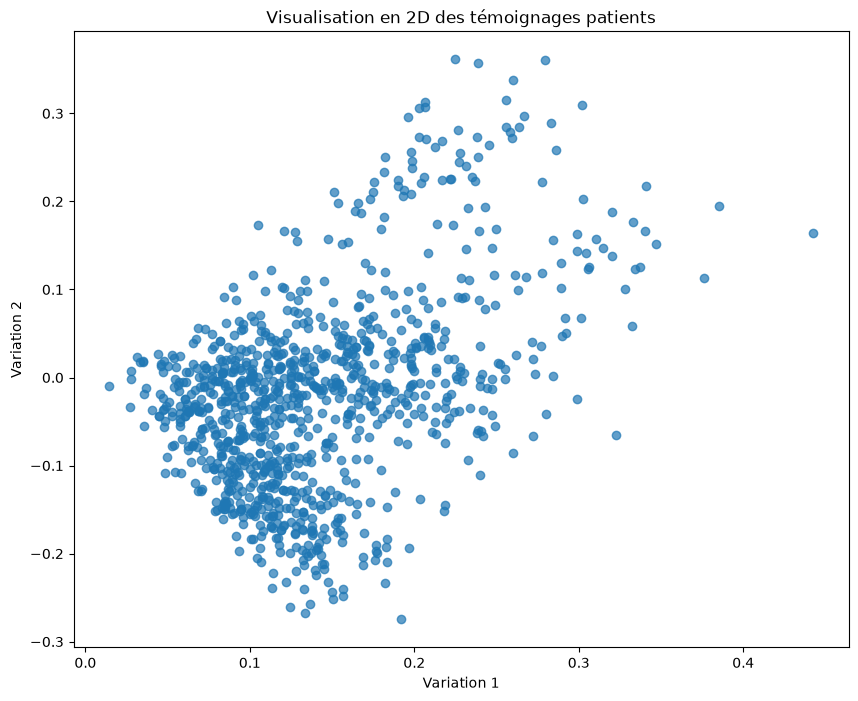

In [ ]:
# on passe sur 2 axes principaux sinon le graphique ne va pas réussir à afficher nos data
svd_2d = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd_2d.fit_transform(X)

couleurs_hex = df['Temoignage'] 


plt.figure(figsize=(10, 8))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.7)

plt.title("Visualisation en 2D des témoignages patients")
plt.xlabel("Variation 1")
plt.ylabel("Variation 2")
plt.show()

raise SystemExit(0)

Ce graphique confirme bien nos analyses bien qu'il soit en 2D. On voit un nuage de points en continu et non plusieurs petites îles séparées. DBSCAN n'est donc pas un modèle viable pour notre dataset.

## Loss function

DBSCAN est une exception il n'a pas de loss function, le modèle ne fait pas de système d'erreur et n'essaye pas de se corriger. Il ne fait qu'appliquer une règle mathématique donc ne possède pas de Loss function.